In order to run this notebook: Please install the codebase for ncsnv2 from https://github.com/pronoma/ALS, then install python 3.9, and create a new python virtual environment using:
```python3 -m venv myenv```
where venv is your virtual environment. Activate your environment using the command: ```myenv/bin/activate```. After this install all necessary packages provided in the requirement.txt file using: ```pip install -r requirement.txt```. To set up a new ipykernel type the command ```python3 -m ipykernel install --user --name=ncsnv2```. Next run the jupyter notebook by entering the command ```jupyter notebook``` and opening the provided url on a browser, followed by entering the notebook ALS_Tutorial.ipynb. Open the ncsnv2 kernel and run the cells. 

# Score estimation by score matching

We will first show various score matching techniques on the Swiss roll dataset. This consists of points scattered in the 2D space in the form of a Swiss roll. Each point in the image below is a sample point in our dataset

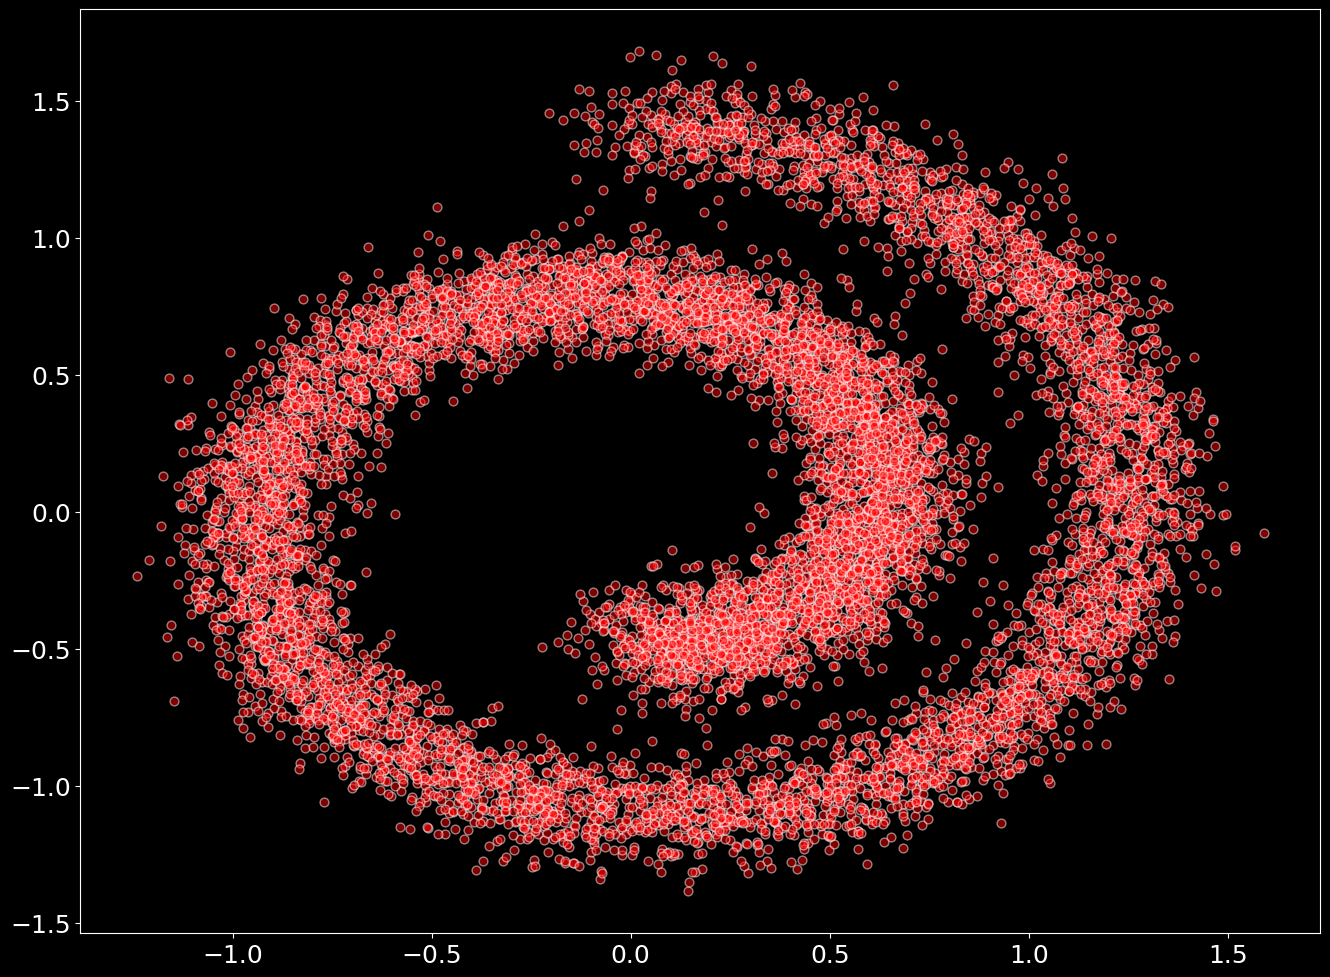

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import make_swiss_roll
from helper_plot import hdr_plot_style
hdr_plot_style()
# Sample a batch of datapoints from the swiss roll dataset
def sample_batch(size, noise=1.0):
    x, _= make_swiss_roll(size, noise=noise) #generates size number of points from the swiss roll dataset with added noise of variance 1.0
    return x[:, [0, 2]] / 10.0
# Plot it
data = sample_batch(10**4).T # Generate 10000 points from swiss roll
plt.figure(figsize=(16, 12))
plt.scatter(*data, alpha=0.5, color='red', edgecolor='white', s=40)

Given IID samples $\{\mathbf{x}_1, \mathbf{x}_2, ..., \mathbf{x}_n\} \sim p_{\text{data}}(\mathbf{x})$, score matching aims to estimate the score function $\nabla_\mathbf{x} \text{ log }p(\mathbf{x})$. The score model is a learnable vector-valued function $s_\theta(\mathbf{x}): \mathbb{R} \rightarrow \mathbb{R}$ which estimates $\nabla_\mathbf{x} \text{ log }p(\mathbf{x})$, i.e., if $s_\theta^*(\mathbf{x})$ is the optimum score obtained after training the model, then $s_\theta^*(\mathbf{x}) \approx \nabla_\mathbf{x} \text{ log }p(\mathbf{x})$. The objective is to minimize the Fischer divergence
$$\frac{1}{2} {E}_{\mathbf{x} \sim p_{\text{data}}} \left[\left\|\nabla_{\mathbf{x}} \log p_{\text{data}}(\mathbf{x}) - \mathbf{s}_\theta(\mathbf{x})\right\|_2^2\right]$$
However, $\log p_{\text{data}}(\mathbf{x})$ is unknown, hence on applying integration by parts on the above equation and under some regularity conditions, the above equation is modified to provide the score matching objective: 
$$\mathbb{E}_{\mathbf{x} \sim p_{\text{data}}} \left[ \frac{1}{2} \|\mathbf{s}_{\theta}(\mathbf{x})\|_2^2 + \operatorname{tr} \left( \underbrace{\nabla_{\mathbf{x}} \mathbf{s}_{\theta}(\mathbf{x})}_{\text{Jacobian of } \mathbf{s}_{\theta}(\mathbf{x})} \right) \right]$$

We first define $s_\theta(x)$ to be simple 3-layer neural network. 


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
# Our approximation model
model = nn.Sequential(
    nn.Linear(2, 128), nn.Softplus(),
    nn.Linear(128, 128), nn.Softplus(),
    nn.Linear(128, 2)
)
# Create ADAM optimizer over our model
optimizer = optim.Adam(model.parameters(), lr=1e-3)

We next define a function to calculate the Jacobian of any differentiable function. 

In [3]:
import torch.autograd as autograd

def jacobian(f, x):
    """Computes the Jacobian of f w.r.t x.
    :param f: function R^N -> R^N
    :param x: torch.tensor of shape [B, N]
    :return: Jacobian matrix (torch.tensor) of shape [B, N, N]
    """
    B, N = x.shape
    y = f(x)
    jacobian = list()
    for i in range(N):
        v = torch.zeros_like(y)
        v[:, i] = 1.
        dy_i_dx = autograd.grad(y, x, grad_outputs=v, retain_graph=True, create_graph=True, allow_unused=True)[0]  # shape [B, N]
        jacobian.append(dy_i_dx)
    jacobian = torch.stack(jacobian, dim=2).requires_grad_()
    return jacobian


We then compute the score matching loss as following

In [4]:
def score_matching(model, samples, train=False):
    samples.requires_grad_(True)
    logp = model(samples)
    # Compute the norm loss
    norm_loss = torch.norm(logp, dim=-1) ** 2 / 2. # first term
    # Compute the Jacobian loss
    jacob_mat = jacobian(model, samples)
    tr_jacobian_loss = torch.diagonal(jacob_mat, dim1=-2, dim2=-1).sum(-1)
    return (tr_jacobian_loss + norm_loss).mean(-1)

In [5]:
dataset = torch.tensor(data.T).float()
data.shape

(2, 10000)

We now train our model to learn the scores

In [6]:
dataset = torch.tensor(data.T).float()
for t in range(2000):
    # Compute the loss.
    loss = score_matching(model, dataset)
    # Before the backward pass, zero all of the network gradients
    optimizer.zero_grad()
    # Backward pass: compute gradient of the loss with respect to parameters
    loss.backward()
    # Calling the step function to update the parameters
    optimizer.step()
    if ((t % 500) == 0):
        print(loss)

tensor(0.0528, grad_fn=<MeanBackward1>)
tensor(-18.0848, grad_fn=<MeanBackward1>)
tensor(-42.9779, grad_fn=<MeanBackward1>)
tensor(-49.1299, grad_fn=<MeanBackward1>)


We can observe the scores on our data

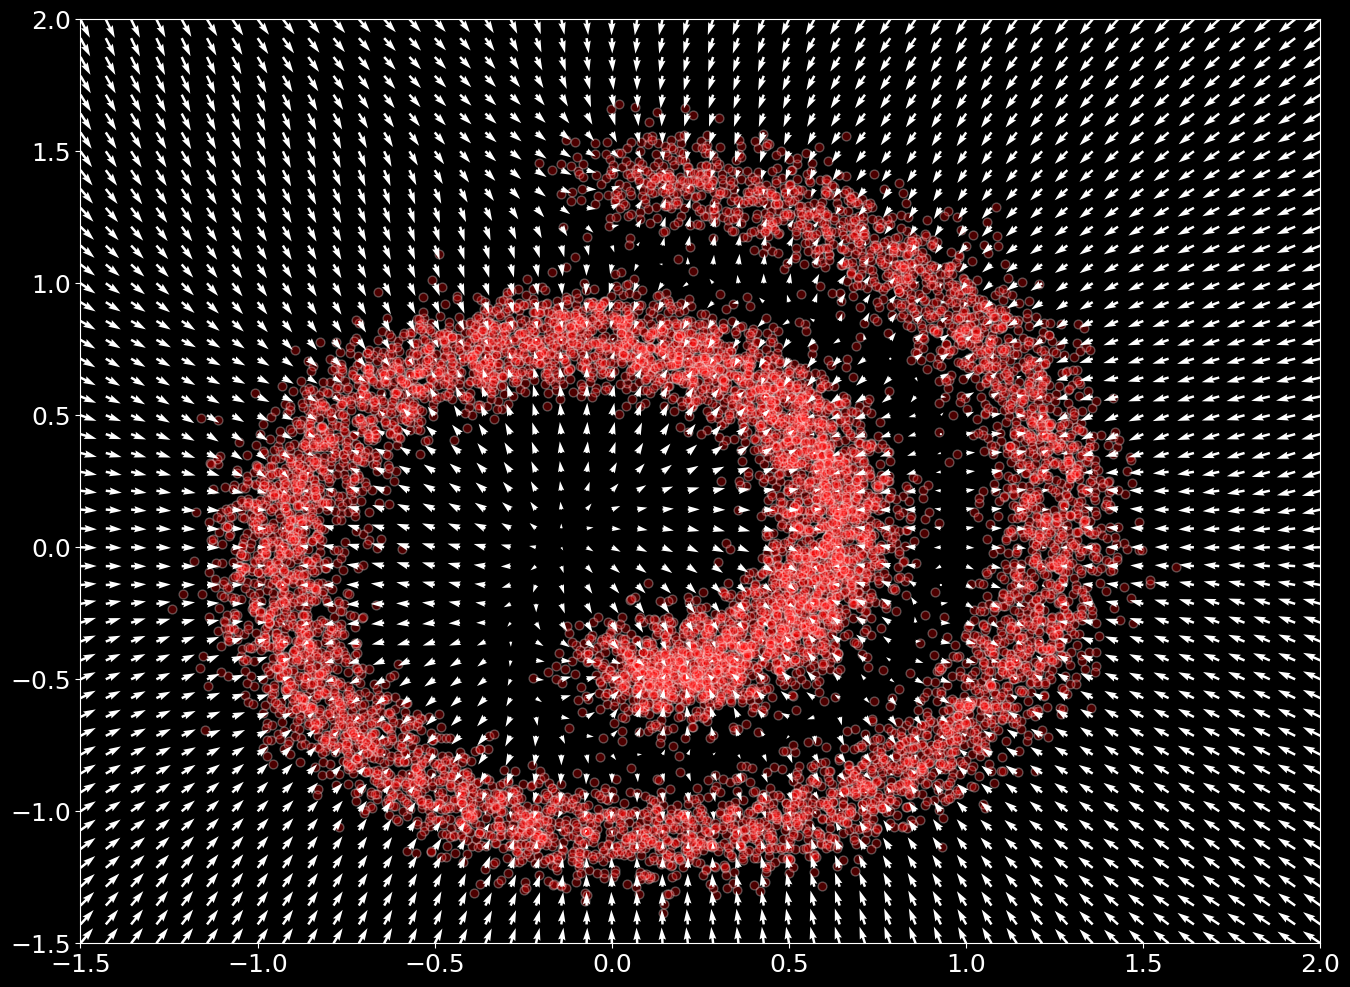

In [7]:
def plot_gradients(model, data, plot_scatter=True):
    xx = np.stack(np.meshgrid(np.linspace(-1.5, 2.0, 50), np.linspace(-1.5, 2.0, 50)), axis=-1).reshape(-1, 2)
    scores = model(torch.tensor(xx).float()).detach()
    scores_norm = np.linalg.norm(scores, axis=-1, ord=2, keepdims=True)
    scores_log1p = scores / (scores_norm + 1e-9) * np.log1p(scores_norm)
    # Perform the plots
    plt.figure(figsize=(16,12))
    if (plot_scatter):
        plt.scatter(*data, alpha=0.3, color='red', edgecolor='white', s=40)
    plt.quiver(*xx.T, *scores_log1p.T, width=0.002, color='white')
    plt.xlim(-1.5, 2.0)
    plt.ylim(-1.5, 2.0)
plot_gradients(model, data)

## Denoising score matching 

The Jacobian calculation, as observed from its implementation, depends on the number of dimensions of the data, and has a time-complexity of $O(d)$, where $d$ is the number of dimensions. While that doesn't matter for this dataset, since it is 2 dimensional, it might be quite slow for image datasets which lie in a much higher dimensional space. Hence Vincent, 2011 suggested the denoising score matching, which makes the time-complexity of the score-estimation independent of the number of dimensions of the samples. In this method, instead of computing the score of the true data density, we compute the score of a noise perturbed data density. 

Consider the perturbed distribution:

$$q_{\sigma}(\tilde{\mathbf{x}} \mid \mathbf{x}) = \mathcal{N}(\mathbf{x}; \sigma^2 \mathbf{I}) \quad q_{\sigma}(\tilde{\mathbf{x}}) = \int p(\mathbf{x}) q_{\sigma}(\tilde{\mathbf{x}} \mid \mathbf{x}) d\mathbf{x}
$$

Hence denoising score matching objective is given by: 

$$\frac{1}{2} \mathbb{E}_{\tilde{\mathbf{x}} \sim q_{\sigma}} \left[ \left\|\nabla_{\tilde{\mathbf{x}}} \log q_{\sigma}(\tilde{\mathbf{x}}) - \mathbf{s}_{\theta}(\tilde{\mathbf{x}})\right\|_2^2 \right]$$

$$ = \frac{1}{2} \mathbb{E}_{\mathbf{x} \sim p_{\text{data}}(\mathbf{x}), \tilde{\mathbf{x}} \sim q_{\sigma}(\tilde{\mathbf{x}} \mid \mathbf{x})} \left[\|\mathbf{s}_{\theta}(\tilde{\mathbf{x}}) - \nabla_{\tilde{\mathbf{x}}} \log q_{\sigma}(\tilde{\mathbf{x}} \mid \mathbf{x})\|_2^2 \right] + \text{const.}
$$

Hence the problem reduces to estimating the noise added to the data 
$q_{\sigma}(\tilde{\mathbf{x}} \mid \mathbf{x}) = \mathcal{N}(\mathbf{x}; \sigma^2 \mathbf{I})$. 
The score estimation is now the same as estimating $\nabla_{\tilde{\mathbf{x}}} \log q_{\sigma}(\tilde{\mathbf{x}} \mid \mathbf{x}) = - \frac{\tilde{x}-x}{\sigma^2}$

We can implement denoising score matching as follows:

In [8]:
def denoising_score_matching(scorenet, samples, sigma=0.01):
    perturbed_samples = samples + torch.randn_like(samples) * sigma
    target = - 1 / (sigma ** 2) * (perturbed_samples - samples)
    scores = scorenet(perturbed_samples)
    target = target.view(target.shape[0], -1)
    scores = scores.view(scores.shape[0], -1)
    loss = 1 / 2. * ((scores - target) ** 2).sum(dim=-1).mean(dim=0)
    return loss

We train our model with the same network and optimizer

In [9]:
import torch
import torch.nn as nn
import torch.optim as optim

# Our approximation model
model = nn.Sequential(
    nn.Linear(2, 128), nn.Softplus(),
    nn.Linear(128, 128), nn.Softplus(),
    nn.Linear(128, 2)
)
# Create ADAM optimizer over our model
optimizer = optim.Adam(model.parameters(), lr=1e-3)
dataset = torch.tensor(data.T).float()
for t in range(5000):
    # Compute the loss.
    loss = denoising_score_matching(model, dataset)
    # Before the backward pass, zero all of the network gradients
    optimizer.zero_grad()
    # Backward pass: compute gradient of the loss with respect to parameters
    loss.backward()
    # Calling the step function to update the parameters
    optimizer.step()
    # Print loss
    if ((t % 1000) == 0):
        print(loss)

tensor(10034.0244, grad_fn=<MulBackward0>)
tensor(9983.2900, grad_fn=<MulBackward0>)
tensor(9996.0869, grad_fn=<MulBackward0>)
tensor(10080.7939, grad_fn=<MulBackward0>)
tensor(9961.1201, grad_fn=<MulBackward0>)


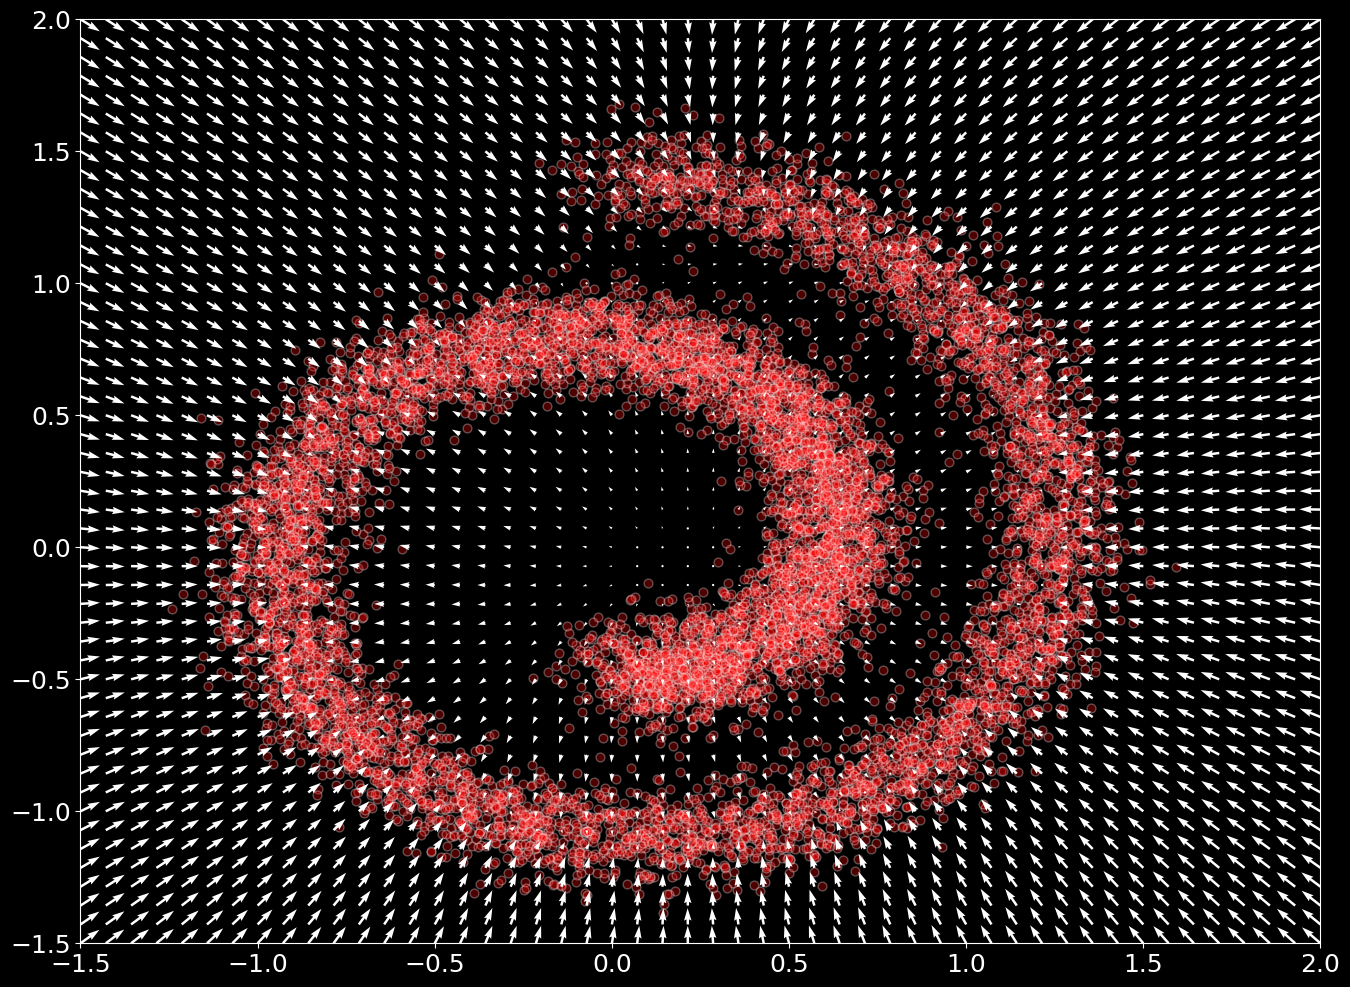

In [10]:
plot_gradients(model, data)

# Langevin dynamics sampling

Langevin dynamics can produce samples from a probability density $p(x)$ using only the score function $\nabla_x \text{log } p(x)$. Given a fixed step size $\epsilon > 0$ and an initial value $\tilde{x_0} \sim \pi(x)$, with $\pi(x)$ being a prior distribution, the Langevin method recursively computes the following: 

$$\tilde{x_t}= \tilde{x_{t-1}} + \frac{\epsilon}{2} \nabla_x \text{log } p(x_{t-1}) + \sqrt{\epsilon} z_t \tag{1}$$

where $z_t \sim \mathcal{N}(0, I)$. It has been shown in Welling et. al., 2011 that as $\epsilon\to 0$ and $T \to \infty$, $\tilde{x_T}$ becomes an exact sample from $p(x)$, which is the key idea in all discrete-time score-based generative modelling approaches. 

In [11]:
def sample_simple2(model, sample_num, n_steps=20, eps=1e-3):
    with torch.no_grad():
        x_init = torch.randn(size=(sample_num, 2))
        denoised_x = torch.zeros((n_steps, x_init.shape[0], x_init.shape[1]))
        denoised_x[0] = x_init
        for s in range(1, n_steps):
            z_t = torch.rand(denoised_x[s].size())
            denoised_x[s] = denoised_x[s-1] + (eps / 2) * model(denoised_x[s-1]) + (np.sqrt(eps) * z_t)
        return denoised_x

In [12]:
import matplotlib.pyplot as plt
import torch
from matplotlib.animation import FuncAnimation

def create_sampling_animation(denoised_x, n_steps, save_path):
    fig, ax = plt.subplots(figsize=(6, 6))
    scatter = ax.scatter([], [], alpha=0.1, s=1)

    def init():
        ax.set_xlim(-3, 3)
        ax.set_ylim(-3, 3)
        ax.set_xlabel("x")
        ax.set_ylabel("y")
        ax.set_title("Sampling")
        return (scatter,)

    def update(rev_t):
        # Update scatter plot
        t = rev_t
        scatter.set_offsets(denoised_x[t])
        ax.set_title(f"Sampling - Step {t}/{n_steps}")
        return (scatter,)

    # Create animation
    anim = FuncAnimation(fig, update, frames=n_steps, init_func=init, blit=True)
    # Save animation as video
    anim.save(save_path, writer="pillow", fps=20)
    plt.close(fig)
    print("Finish saving gif file: ", save_path)

In [13]:
model_path = "diffusion_model.pth"
sample_num = 100000
n_steps = 20
eps=1e-3
denoised_x = sample_simple2(model, sample_num, n_steps, eps=1e-3) #Here model is the model for vanilla score matching
save_path = "sampling.gif"
create_sampling_animation(denoised_x, n_steps, save_path)

Finish saving gif file:  sampling.gif


<img src="sampling.gif" width="750" align="center">

# Noise-Conditional Score Networks

Song *et al.* expanded the idea of denoising score matching to score-based sampling. The key idea proposed by them is that perturbing the data with random Gaussian noise makes the support of the data distribution equivalent to the ambient space. Hence the perturbed data is no longer confined to a lower dimensional manifold. Further, large Gaussian noise has the effect of filling low density regions in the original unperturbed distribution, hence the training by sample approximation is better at low density regions, resulting in improved score estimation. The authors use 2 key observations
1. High noise provides useful directional information for Langevin dynamics 
2. However, perturbed density no longer approximates the true data density 

The authors define a noise conditional score network to predict the scores for $L$ noise levels simultaneously. The noise levels form a positive geometric sequence that satisfies $\frac{\sigma_1}{\sigma_2} = \cdots = \frac{\sigma_{L-1}}{\sigma_L} > 1$, where $\sigma_1$ is large enough to mitigate the difficulties with score based sampling, and $\sigma_L \approx 0$. This method makes sure that we utilize the directional information provided by the higher noise perturbation, while closely approximating the true density eventually.

The noise density is chosen to be $q_\sigma (\tilde{x}\mid x, \sigma^2I)$, hence $\nabla_{\tilde{\mathbf{x}}} \log q_{\sigma}(\tilde{\mathbf{x}} \mid \mathbf{x}) = - \frac{\tilde{x}-x}{\sigma^2}$. Given the denoising score matching objective: 

$$l(\theta, \sigma) = \frac{1}{2} \mathbb{E}_{q_\sigma(\tilde{x} \mid x)p_{data}(x)}\left[ \left\|\mathbf{s}_{\theta}(\tilde{\mathbf{x}}, \sigma) + \frac{\tilde{\mathbf{x}} - \mathbf{x}}{\sigma^2}\right\|_2^2 \right] \tag{2}$$

The objective function for the NCSN is then given by: 

$$\mathcal{L}(\theta; \{\sigma_i\}_{i=1}^L) = \frac{1}{L}\sum_{i=1}^L \lambda(\sigma_i) l(\theta, \sigma_i)\tag{3}$$

where $\lambda(\sigma_i) > 0$ is a coefficient function depending on $\sigma_i$. This objective can be implemented as follows:


In [14]:
def anneal_dsm_score_estimation(model, samples, labels, sigmas, anneal_power=2.):
    used_sigmas = sigmas[labels].view(samples.shape[0], *([1] * len(samples.shape[1:])))
    perturbed_samples = samples + torch.randn_like(samples) * used_sigmas
    target = - 1 / (used_sigmas ** 2) * (perturbed_samples - samples)
    scores = model(perturbed_samples, labels)
    target = target.view(target.shape[0], -1)
    scores = scores.view(scores.shape[0], -1)
    loss = 1 / 2. * ((scores - target) ** 2).sum(dim=-1) * used_sigmas.squeeze() ** anneal_power
    return loss.mean(dim=0)

Hence the score model is a conditional network which takes as input the different noise levels $\sigma_i$. We can define the model in the following way:

In [15]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

class ConditionalLinear(nn.Module):
    def __init__(self, num_in, num_out, num_classes):
        super().__init__()
        self.num_out = num_out
        self.lin = nn.Linear(num_in, num_out)
        self.embed = nn.Embedding(num_classes, num_out)
        self.embed.weight.data.uniform_()

    def forward(self, x, y):
        out = self.lin(x) 
        gamma = self.embed(y) #nn.Embedding(num_classes, num_out) maps each class label y to a vector of size num_out
        out = gamma.view(-1, self.num_out) * out
        return out
    
class ConditionalModel(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.lin1 = ConditionalLinear(2, 128, num_classes) 
        self.lin2 = ConditionalLinear(128, 128, num_classes)
        self.lin3 = nn.Linear(128, 2)
    
    def forward(self, x, y):
        x = F.softplus(self.lin1(x, y)) #log(1+e^x)
        x = F.softplus(self.lin2(x, y))
        return self.lin3(x)

Given the modified network, we can perform the optimization as follows:

In [16]:
import numpy as np
sigma_begin = 1
sigma_end = 0.01
num_classes = 4
sigmas = torch.tensor(np.exp(np.linspace(np.log(sigma_begin), np.log(sigma_end), num_classes))).float()
# Our approximation model
model2 = ConditionalModel(num_classes)
dataset = torch.tensor(data.T).float()
# Create ADAM optimizer over our model
optimizer = optim.Adam(model2.parameters(), lr=1e-3)
for t in range(5000):
    # Compute the loss.
    labels = torch.randint(0, len(sigmas), (dataset.shape[0],))
    loss = anneal_dsm_score_estimation(model2, dataset, labels, sigmas)
    # Before the backward pass, zero all of the network gradients
    optimizer.zero_grad()
    # Backward pass: compute gradient of the loss with respect to parameters
    loss.backward()
    # Calling the step function to update the parameters
    optimizer.step()
    # Print loss
    if ((t % 1000) == 0):
        print(loss)

tensor(1.0299, grad_fn=<MeanBackward1>)
tensor(0.8051, grad_fn=<MeanBackward1>)
tensor(0.7910, grad_fn=<MeanBackward1>)
tensor(0.7517, grad_fn=<MeanBackward1>)
tensor(0.7724, grad_fn=<MeanBackward1>)


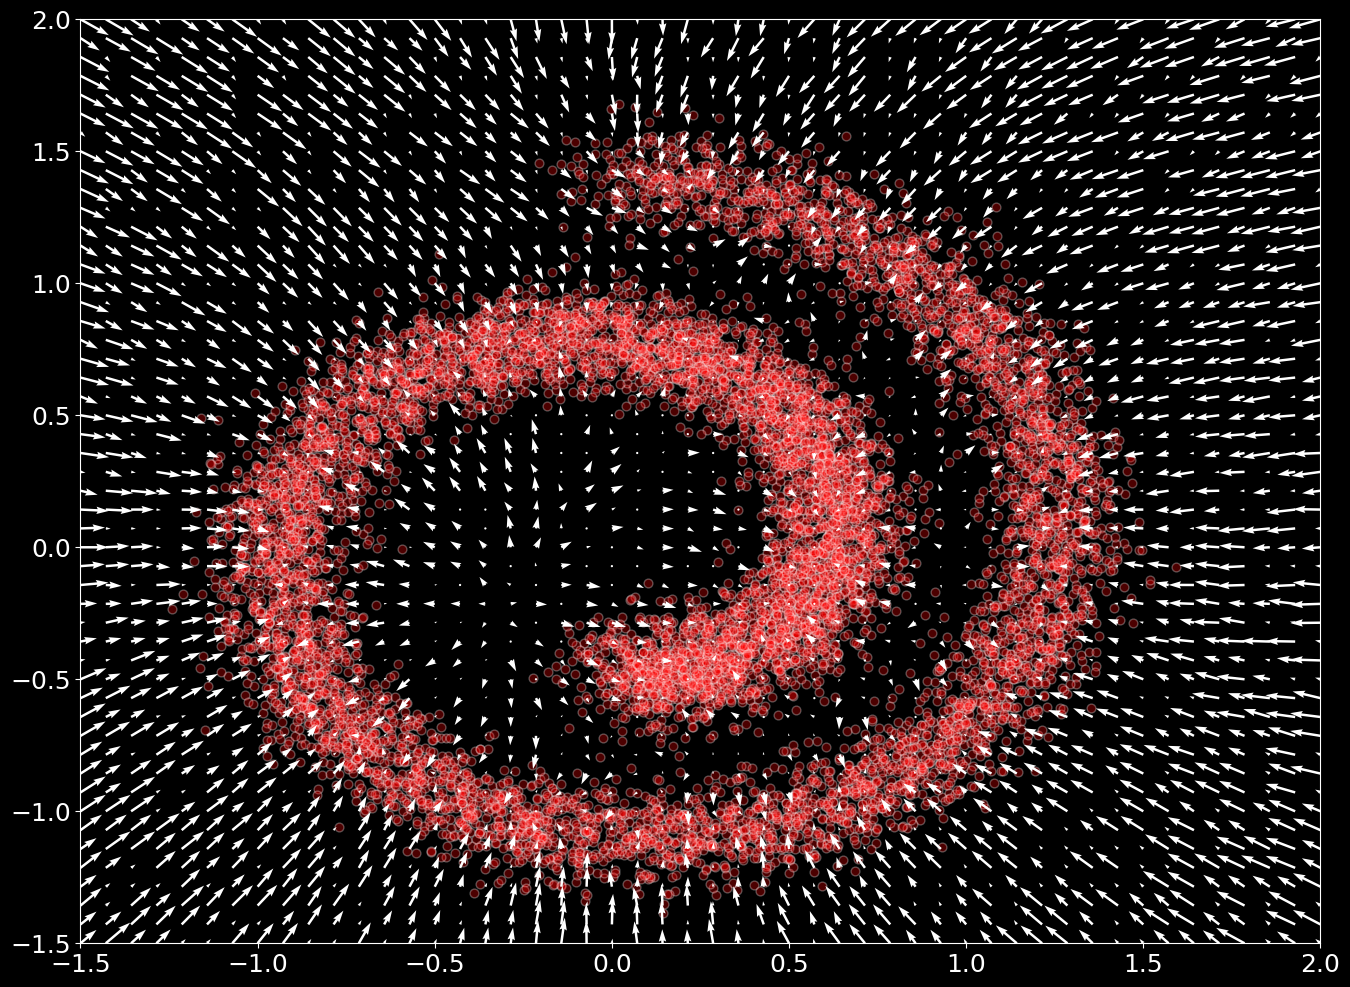

In [17]:
xx = np.stack(np.meshgrid(np.linspace(-1.5, 2.0, 50), np.linspace(-1.5, 2.0, 50)), axis=-1).reshape(-1, 2)
labels = torch.randint(0, len(sigmas), (xx.shape[0],))
# print(labels)
scores = model2(torch.tensor(xx).float(), labels).detach()
# print(scores)
scores_norm = np.linalg.norm(scores, axis=-1, ord=2, keepdims=True)
scores_log1p = scores / (scores_norm + 1e-9) * np.log1p(scores_norm)
# Perform the plots
plt.figure(figsize=(16,12))
plt.scatter(*data, alpha=0.3, color='red', edgecolor='white', s=40)
plt.quiver(*xx.T, *scores_log1p.T, width=0.002, color='white')
plt.xlim(-1.5, 2.0)
plt.ylim(-1.5, 2.0);

## Annealed Langevin dynamics sampling

Once the scores corresponding to each noise level is obtained from NCSN, we perform the annealed Langevin dynamics sampling to generate samples from the true data density $p_{data}$. The algorithm for Annealed Langevin dynamics sampling is as follows:

**Algorithm 1**: **Annealed Langevin dynamics.**  

**Require:** $\{\sigma_i\}_{i=1}^{L}, \epsilon, T$.  
1: Initialize $\tilde{\mathbf{x}}_0$  
2: **for** $i \gets 1$ to $L$ **do**  
3: $\quad \alpha_i \gets \epsilon \cdot \sigma_i^2 / \sigma_L^2$  ⬅️  $\alpha_i$ is the step size.  
4: $\quad$ **for** $t \gets 1$ to $T$ **do**  
5: $\quad\quad$ Draw $\mathbf{z}_t \sim \mathcal{N}(0, I)$  
6: $\quad\quad$ $\tilde{\mathbf{x}}_t \gets \tilde{\mathbf{x}}_{t-1} + \frac{\alpha_i}{2} \mathbf{s}_{\theta}(\tilde{\mathbf{x}}_{t-1}, \sigma_i) + \sqrt{\alpha_i} \mathbf{z}_t$  
7: $\quad$ **end for**  
8: $\quad$ $\tilde{\mathbf{x}}_0 \gets \tilde{\mathbf{x}}_T$  
9: **end for**  
    **return** denoised sample $\tilde{\mathbf{x}}_T + \sigma_T^2 \mathbf{s}_{\theta}({\mathbf{x}_T, \sigma_T})$  

This algorithm is implemented as follows:


In [113]:
def sample_anneal(model, sample_num, n_steps=20, eps=0.000008):
    with torch.no_grad():
        x_init = torch.randn(size=(sample_num, 2))
        denoised_x = torch.zeros((n_steps*sigmas.shape[0], x_init.shape[0], x_init.shape[1]))
        # print(denoised_x.shape)
        denoised_x[0] = x_init
        for c, sigma in enumerate(sigmas):
            # print(c)
            step_size = eps * (sigma / sigmas[-1]) ** 2
            
            if c>0:
                denoised_x[n_steps*c] = denoised_x[n_steps*c-1]
                
            for s in range(1, n_steps):
                z_t = torch.rand(denoised_x[s+n_steps*c].size())
                denoised_x[s+n_steps*c] = denoised_x[s+n_steps*c-1] + (step_size / 2) * model(denoised_x[s+n_steps*c-1]) + (np.sqrt(step_size) * z_t)
            
            # level = level+1
            print(c)
        return denoised_x

In [111]:
import matplotlib.pyplot as plt
import torch
from matplotlib.animation import FuncAnimation

def create_sampling_animation(denoised_x, n_steps, save_path):
    fig, ax = plt.subplots(figsize=(6, 6))
    scatter = ax.scatter([], [], alpha=0.1, s=1)

    def init():
        ax.set_xlim(-3, 3)
        ax.set_ylim(-3, 3)
        ax.set_xlabel("x")
        ax.set_ylabel("y")
        ax.set_title("Sampling")
        return (scatter,)

    def update(rev_t):
        # Update scatter plot
        t = rev_t
        scatter.set_offsets(denoised_x[t])
        ax.set_title(f"Sampling - Step {t}/{n_steps}")
        return (scatter,)

    # Create animation
    anim = FuncAnimation(fig, update, frames=n_steps, init_func=init, blit=True)
    # Save animation as video
    anim.save(save_path, writer="pillow", fps=20)
    plt.close(fig)
    print("Finish saving gif file: ", save_path)

In [112]:
model_path = "diffusion_model.pth"
sample_num = 100000
n_steps = 20
eps= 0.000008
denoised_x = sample_anneal(model, sample_num, n_steps, eps) #Here model is the model for vanilla score matching
save_path = "sampling_anneal.gif"
create_sampling_animation(denoised_x, n_steps*sigmas.shape[0], save_path)

0
1
2
3
Finish saving gif file:  sampling_anneal.gif


<img src="sampling_anneal.gif" width="750" align="center">

In [ ]:
def anneal_Langevin_dynamics2(num_samples, scorenet, sigmas, n_steps_each=200, step_lr=0.000008,
                             final_only=False, verbose=False, denoise=True):
    images = []
    x_init = torch.randn(size=(num_samples, 2))
    x_mod = torch.zeros((n_steps_each*sigmas.shape, x_init.shape[0], x_init.shape[1]))
    x_mod[0] = x_init
# x_sequence.append(x.unsqueeze(0))
    # return torch.cat(x_sequence)
    with torch.no_grad():
        for c, sigma in enumerate(sigmas):
            # pdb.set_trace()
            labels = torch.ones(x_mod.shape[0], device=x_mod.device) * c
            labels = labels.long()
            step_size = step_lr * (sigma / sigmas[-1]) ** 2
            for s in range(n_steps_each):
                grad = scorenet(x_mod[c*s], labels)

                noise = torch.randn_like(x_mod[c*s])
                # grad_norm = torch.norm(grad.view(grad.shape[0], -1), dim=-1).mean()
                # noise_norm = torch.norm(noise.view(noise.shape[0], -1), dim=-1).mean()
                x_mod[c*s] = x_mod[c*s-1] + step_size * grad + noise * np.sqrt(step_size * 2)

                # image_norm = torch.norm(x_mod.view(x_mod.shape[0], -1), dim=-1).mean()
                # snr = np.sqrt(step_size / 2.) * grad_norm / noise_norm
                # grad_mean_norm = torch.norm(grad.mean(dim=0).view(-1)) ** 2 * sigma ** 2

                if not final_only:
                    images.append(x_mod.to('cpu'))
                if verbose:
                    print("level: {}, step_size: {}, grad_norm: {}, image_norm: {}, snr: {}, grad_mean_norm: {}".format(
                        c, step_size, grad_norm.item(), image_norm.item(), snr.item(), grad_mean_norm.item()))

        if denoise:
            last_noise = (len(sigmas) - 1) * torch.ones(x_mod[n_steps_each*sigmas.shape-1].shape[0], device=x_mod.device)
            last_noise = last_noise.long()
            x_mod[n_steps_each*sigmas.shape-1] = x_mod[n_steps_each*sigmas.shape-1] + sigmas[-1] ** 2 * scorenet(x_mod[n_steps_each*sigmas.shape-1], last_noise)
            images.append(x_mod[n_steps_each*sigmas.shape-1].to('cpu'))

        if final_only:
            return [x_mod[n_steps_each*sigmas.shape-1].to('cpu')]
        else:
            return torch.cat(images)

In [ ]:
samples = anneal_Langevin_dynamics2(10000, model2, sigmas, n_steps_each=200, step_lr=0.000008,
                             final_only=False, verbose=False, denoise=True).detach()

# ALS for Image generation (FFHQ dataset)

We will now repeat our experiments on score estimation and annealed Langevin sampling for image generation. We use the FFHQ dataset with 70000 images of size 256x256 for our experiments. 

## Noise Conditional Score Network

The NCSN network for image generation as developed by Yang Song, is based out of the RefineNet architecture, which is a classical network architecture for semantic segmentation. There are three major modifications to the original RefineNet in NCSN
1. **Adding an enhanced version of conditional instance normalization for every convolutional layer**: Instance normalization normalizes feature maps per instance (per image or sample) and per channel in a batch. In the usual case the normalization parameters (i.e. the mean and variance of the convolutional kernel is fixed. Conditional instance normalization learns different affine transformation (scale and shift) parameters conditioned on an external input. Given a condition $c$ (such as a class label), the scale parameter $\gamma(c)$ and shift parameter $\beta(c)$ are applied as follows:
   $$\hat{x}= \frac{x-\mu}{\sigma} \gamma(c) + \beta(c)$$
However this is not applied for the network used to train on FFHQ dataset. However it does do instance normalization as follows:

Given an input feature map $x$ of shape [Batch, Channels, Height, Width], instance normalization normalizes each feature map independently across its spatial dimensions.

$$\hat{x}_{i,c} = \frac{x_{i,c} - \mu_{i,c}}{\sigma_{i,c} + \epsilon}$$


where:

- $x_{i,c}$ is the feature map for instance $i$ and channel $c$.

- $\mu_{i,c}$ = Mean of the instance's channel:

$$\mu_{i,c} = \frac{1}{H \times W} \sum_{h=1}^{H} \sum_{w=1}^{W} x_{i,c,h,w}$$

- $\sigma_{i,c}^2$ = Variance of the instance's channel:
$$
\sigma_{i,c}^2 = \frac{1}{H \times W} \sum_{h=1}^{H} \sum_{w=1}^{W} \left( x_{i,c,h,w} - \mu_{i,c} \right)^2
$$

- $\epsilon$ is a small constant to prevent division by zero.


3. **Using dilated convolutions in the ResNet backend of RefineNet:**
   A standard convolution applies a kernel of size $k \times k$:

$$
\text{output}(i, j) = \sum_{m=-\frac{k-1}{2}}^{\frac{k-1}{2}} \sum_{n=-\frac{k-1}{2}}^{\frac{k-1}{2}} W(m,n) \cdot x(i + m, j + n)
$$

For a **dilated convolution** with **dilation rate** $d$, the kernel skips $d - 1$ pixels between elements:

$$
\text{output}(i, j) = \sum_{m=-\frac{k-1}{2}}^{\frac{k-1}{2}} \sum_{n=-\frac{k-1}{2}}^{\frac{k-1}{2}} W(m,n) \cdot x(i + d \cdot m, j + d \cdot n)
$$

where:
- $k$ is the **kernel size** (assumed to be odd for centered indexing).
- $m, n$ are the indices **spanning the kernel size**.
- $W(m, n)$ represents the convolution kernel weights.
- $x(i, j)$ is the input feature map.
- $d$ is the **dilation rate**, which increases the receptive field without increasing the number of parameters.

A ResNet block is called "ResBlock" and a RefineNet block “RefineBlock". When Conditional Instance norm is added the network blocks are called "CondResBlock" and "CondRefineBlock" respectively. ELU activation function is used throughout all architectures.  

To ensure that there is no compromise in performance because of image size, larger images use deeper networks. Our dataset of size 256x256 was the largest image size used for all experiments in the paper, hence it uses the deepest CNN architecture, called NCSNv2Deepest.

\begin{array}{c}
\hline\hline
\textbf{3x3 Conv2D, 128} \\
\hline
\text{ResBlock, 128} \\
\hline
\text{ResBlock, 128} \\
\hline
\text{ResBlock down, 256} \\
\hline
\text{ResBlock, 256} \\
\hline
\text{ResBlock down, 256} \\
\hline
\text{ResBlock, 256} \\
\hline
\text{ResBlock down, 256} \\
\hline
\text{ResBlock, 256} \\
\hline
\text{ResBlock down, 512} \\
\text{dilation 2} \\
\hline
\text{ResBlock, 512} \\
\text{dilation 2} \\
\hline
\text{ResBlock down, 512} \\
\text{dilation 4} \\
\hline
\text{ResBlock, 512} \\
\text{dilation 4} \\
\hline
\text{RefineBlock, 512} \\
\hline
\text{RefineBlock, 256} \\
\hline
\text{RefineBlock, 256} \\
\hline
\text{RefineBlock, 256} \\
\hline
\text{RefineBlock, 128} \\
\hline
\text{RefineBlock, 128} \\
\hline
\textbf{3x3 Conv2D, 3} \\
\hline
\end{array}

In [ ]:
import torch.nn as nn
import numpy as np
import torch.nn.functional as F
import torch
from functools import partial
# from . import get_sigmas
# from .layers import *
# from .normalization import get_normalization

In [ ]:
def get_sigmas(sigma_dist, sigma_begin, sigma_end, num_classes):
    if sigma_dist == 'geometric':
        sigmas = torch.tensor(
            np.exp(np.linspace(np.log(sigma_begin), np.log(sigma_end),
                               num_classes))).float().to(device)
    elif sigma_dist == 'uniform':
        sigmas = torch.tensor(
            np.linspace(sigma_begin, sigma_end, num_classes)
        ).float().to(device)

    else:
        raise NotImplementedError('sigma distribution not supported')

    return sigmas

In [ ]:
import torch
import torch.nn as nn


def get_normalization(norm, conditional=True):
    # norm = 'InstanceNorm++'
    if conditional:
        if norm == 'NoneNorm':
            return ConditionalNoneNorm2d
        elif norm == 'InstanceNorm++':
            return ConditionalInstanceNorm2dPlus
        elif norm == 'InstanceNorm':
            return ConditionalInstanceNorm2d
        elif norm == 'BatchNorm':
            return ConditionalBatchNorm2d
        elif norm == 'VarianceNorm':
            return ConditionalVarianceNorm2d
        else:
            raise NotImplementedError("{} does not exist!".format(norm))
    else:
        if norm == 'BatchNorm':
            return nn.BatchNorm2d
        elif norm == 'InstanceNorm':
            return nn.InstanceNorm2d
        elif norm == 'InstanceNorm++':
            return InstanceNorm2dPlus
        elif norm == 'VarianceNorm':
            return VarianceNorm2d
        elif norm == 'NoneNorm':
            return NoneNorm2d
        elif norm is None:
            return None
        else:
            raise NotImplementedError("{} does not exist!".format(norm))

class InstanceNorm2dPlus(nn.Module):
    def __init__(self, num_features, bias=True):
        super().__init__()
        self.num_features = num_features
        self.bias = bias
        self.instance_norm = nn.InstanceNorm2d(num_features, affine=False, track_running_stats=False)
        self.alpha = nn.Parameter(torch.zeros(num_features))
        self.gamma = nn.Parameter(torch.zeros(num_features))
        self.alpha.data.normal_(1, 0.02)
        self.gamma.data.normal_(1, 0.02)
        if bias:
            self.beta = nn.Parameter(torch.zeros(num_features))

    def forward(self, x):
        means = torch.mean(x, dim=(2, 3))
        m = torch.mean(means, dim=-1, keepdim=True)
        v = torch.var(means, dim=-1, keepdim=True)
        means = (means - m) / (torch.sqrt(v + 1e-5))
        h = self.instance_norm(x)

        if self.bias:
            h = h + means[..., None, None] * self.alpha[..., None, None]
            out = self.gamma.view(-1, self.num_features, 1, 1) * h + self.beta.view(-1, self.num_features, 1, 1)
        else:
            h = h + means[..., None, None] * self.alpha[..., None, None]
            out = self.gamma.view(-1, self.num_features, 1, 1) * h
        return out

In [ ]:
def get_act(nonlinearity):
    if nonlinearity == 'elu':
        return nn.ELU()
    elif nonlinearity == 'relu':
        return nn.ReLU()
    elif nonlinearity == 'lrelu':
        return nn.LeakyReLU(negative_slope=0.2)
    elif nonlinearity == 'swish':
        def swish(x):
            return x * torch.sigmoid(x)
        return swish
    else:
        raise NotImplementedError('activation function does not exist!')

In [ ]:
class NCSNv2Deepest(nn.Module):
    def __init__(self):
        super().__init__()
        self.logit_transform = false
        self.rescaled = false
        self.norm = get_normalization(norm='InstanceNorm++', conditional=False)
        self.ngf = ngf = 128
        self.num_classes = 2311
        self.act = act = get_act(nonlinearity = 'elu')
        self.register_buffer('sigmas', get_sigmas(sigma_dist = 'geometric', sigma_begin=348, sigma_end=0.01, num_classes=2311))
        self.channels=3
        # self.config = config

        self.begin_conv = nn.Conv2d(self.channels, ngf, 3, stride=1, padding=1)
        self.normalizer = self.norm(ngf, self.num_classes)

        self.end_conv = nn.Conv2d(ngf, self.channels, 3, stride=1, padding=1)

        self.res1 = nn.ModuleList([
            ResidualBlock(self.ngf, self.ngf, resample=None, act=act,
                          normalization=self.norm),
            ResidualBlock(self.ngf, self.ngf, resample=None, act=act,
                          normalization=self.norm)]
        )

        self.res2 = nn.ModuleList([
            ResidualBlock(self.ngf, 2 * self.ngf, resample='down', act=act,
                          normalization=self.norm),
            ResidualBlock(2 * self.ngf, 2 * self.ngf, resample=None, act=act,
                          normalization=self.norm)]
        )

        self.res3 = nn.ModuleList([
            ResidualBlock(2 * self.ngf, 2 * self.ngf, resample='down', act=act,
                          normalization=self.norm),
            ResidualBlock(2 * self.ngf, 2 * self.ngf, resample=None, act=act,
                          normalization=self.norm)]
        )

        self.res31 = nn.ModuleList([
            ResidualBlock(2 * self.ngf, 2 * self.ngf, resample='down', act=act,
                          normalization=self.norm),
            ResidualBlock(2 * self.ngf, 2 * self.ngf, resample=None, act=act,
                          normalization=self.norm)]
        )

        self.res4 = nn.ModuleList([
            ResidualBlock(2 * self.ngf, 4 * self.ngf, resample='down', act=act,
                          normalization=self.norm, dilation=2),
            ResidualBlock(4 * self.ngf, 4 * self.ngf, resample=None, act=act,
                          normalization=self.norm, dilation=2)]
        )

        self.res5 = nn.ModuleList([
            ResidualBlock(4 * self.ngf, 4 * self.ngf, resample='down', act=act,
                          normalization=self.norm, dilation=4),
            ResidualBlock(4 * self.ngf, 4 * self.ngf, resample=None, act=act,
                          normalization=self.norm, dilation=4)]
        )

        self.refine1 = RefineBlock([4 * self.ngf], 4 * self.ngf, act=act, start=True)
        self.refine2 = RefineBlock([4 * self.ngf, 4 * self.ngf], 2 * self.ngf, act=act)
        self.refine3 = RefineBlock([2 * self.ngf, 2 * self.ngf], 2 * self.ngf, act=act)
        self.refine31 = RefineBlock([2 * self.ngf, 2 * self.ngf], 2 * self.ngf, act=act)
        self.refine4 = RefineBlock([2 * self.ngf, 2 * self.ngf], self.ngf, act=act)
        self.refine5 = RefineBlock([self.ngf, self.ngf], self.ngf, act=act, end=True)

    def _compute_cond_module(self, module, x):
        for m in module:
            x = m(x)
        return x

    def forward(self, x, y):
        if not self.logit_transform and not self.rescaled:
            h = 2 * x - 1.
        else:
            h = x

        output = self.begin_conv(h)

        layer1 = self._compute_cond_module(self.res1, output)
        layer2 = self._compute_cond_module(self.res2, layer1)
        layer3 = self._compute_cond_module(self.res3, layer2)
        layer31 = self._compute_cond_module(self.res31, layer3)
        layer4 = self._compute_cond_module(self.res4, layer31)
        layer5 = self._compute_cond_module(self.res5, layer4)

        ref1 = self.refine1([layer5], layer5.shape[2:])
        ref2 = self.refine2([layer4, ref1], layer4.shape[2:])
        ref31 = self.refine31([layer31, ref2], layer31.shape[2:])
        ref3 = self.refine3([layer3, ref31], layer3.shape[2:])
        ref4 = self.refine4([layer2, ref3], layer2.shape[2:])
        output = self.refine5([layer1, ref4], layer1.shape[2:])

        output = self.normalizer(output)
        output = self.act(output)
        output = self.end_conv(output)

        used_sigmas = self.sigmas[y].view(x.shape[0], *([1] * len(x.shape[1:])))

        output = output / used_sigmas

        return output


In [ ]:
import os
import torch
import torchvision.transforms as transforms
from torchvision.datasets import CIFAR10, LSUN
from datasets.celeba import CelebA
from datasets.ffhq import FFHQ
from torch.utils.data import Subset
import numpy as np

def get_dataset(data, image_size, random_flip, directory_path):
    if random_flip is False:
        tran_transform = test_transform = transforms.Compose([
            transforms.Resize(image_size),
            transforms.ToTensor()
        ])
    else:
        tran_transform = transforms.Compose([
            transforms.Resize(image_size),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.ToTensor()
        ])
        test_transform = transforms.Compose([
            transforms.Resize(image_size),
            transforms.ToTensor()
        ])

    if data == "FFHQ":
        if random_flip:
            dataset = FFHQ(path=os.path.join(directory_path, 'datasets', 'FFHQ'), transform=transforms.Compose([
                transforms.RandomHorizontalFlip(p=0.5),
                transforms.ToTensor()
            ]), resolution=image_size)
        else:
            dataset = FFHQ(path=os.path.join(directory_path, 'datasets', 'FFHQ'), transform=transforms.ToTensor(),
                           resolution=image_size)

        num_items = len(dataset)
        indices = list(range(num_items))
        random_state = np.random.get_state()
        np.random.seed(2019)
        np.random.shuffle(indices)
        np.random.set_state(random_state)
        train_indices, test_indices = indices[:int(num_items * 0.9)], indices[int(num_items * 0.9):]
        test_dataset = Subset(dataset, test_indices)
        dataset = Subset(dataset, train_indices)

    return dataset, test_dataset

In [ ]:
import numpy as np
import glob
import tqdm
from losses.dsm import anneal_dsm_score_estimation

import torch.nn.functional as F
import logging
import torch
import os
from torchvision.utils import make_grid, save_image
from torch.utils.data import DataLoader
from models.ncsnv2 import NCSNv2Deeper, NCSNv2, NCSNv2Deepest
from models.ncsn import NCSN, NCSNdeeper
from datasets import get_dataset, data_transform, inverse_data_transform
from losses import get_optimizer
from models import (anneal_Langevin_dynamics,
                    anneal_Langevin_dynamics_inpainting,
                    anneal_Langevin_dynamics_interpolation,
                    )
from models import get_sigmas
from models.ema import EMAHelper
import pdb

In [ ]:
__all__ = ['NCSNRunner']

In [ ]:
def get_model(data):
    # if data == 'CIFAR10' or config.data.dataset == 'CELEBA':
    #     return NCSNv2(config).to(config.device)
    if data == "FFHQ":
        return NCSNv2Deepest().to(device)
    # elif config.data.dataset == 'LSUN':
    #     return NCSNv2Deeper(config).to(config.device)

In [ ]:
import torch.optim as optim
def get_optimizer(optimizer, lr, weight_decay, beta1, amsgrad, eps, parameters):
    if optimizer == 'Adam':
        return optim.Adam(parameters, lr=config.optim.lr, weight_decay=config.optim.weight_decay,
                          betas=(config.optim.beta1, 0.999), amsgrad=config.optim.amsgrad,
                          eps=config.optim.eps)
    elif config.optim.optimizer == 'RMSProp':
        return optim.RMSprop(parameters, lr=config.optim.lr, weight_decay=config.optim.weight_decay)
    elif config.optim.optimizer == 'SGD':
        return optim.SGD(parameters, lr=config.optim.lr, momentum=0.9)
    else:
        raise NotImplementedError('Optimizer {} not understood.'.format(config.optim.optimizer))

In [ ]:
def data_transform(uniform_dequantization, gaussian_dequantization, rescaled, logit_transform, X):
    if uniform_dequantization:
        X = X / 256. * 255. + torch.rand_like(X) / 256.
    if gaussian_dequantization:
        X = X + torch.randn_like(X) * 0.01

    if rescaled:
        X = 2 * X - 1.
    elif logit_transform:
        X = logit_transform(X)

    # if hasattr(config, 'image_mean'):
    #     return X - config.image_mean.to(X.device)[None, ...]

    return X

def inverse_data_transform(logit_transform, rescaled, X):
    # if hasattr(config, 'image_mean'):
    #     X = X + config.image_mean.to(X.device)[None, ...]

    if logit_transform:
        X = torch.sigmoid(X)
    elif rescaled:
        X = (X + 1.) / 2.

    return torch.clamp(X, 0.0, 1.0)

In [ ]:
import torch

def anneal_dsm_score_estimation(scorenet, samples, sigmas, labels=None, anneal_power=2., hook=None):
    if labels is None:
        labels = torch.randint(0, len(sigmas), (samples.shape[0],), device=samples.device)
    used_sigmas = sigmas[labels].view(samples.shape[0], *([1] * len(samples.shape[1:])))
    noise = torch.randn_like(samples) * used_sigmas
    perturbed_samples = samples + noise
    target = - 1 / (used_sigmas ** 2) * noise
    scores = scorenet(perturbed_samples, labels)
    target = target.view(target.shape[0], -1)
    scores = scores.view(scores.shape[0], -1)
    loss = 1 / 2. * ((scores - target) ** 2).sum(dim=-1) * used_sigmas.squeeze() ** anneal_power

    if hook is not None:
        hook(loss, labels)

    return loss.mean(dim=0)


In [ ]:
class NCSNRunner():
    def __init__(self, log_path):
        # self.args = args
        # self.config = config
        self.log_path=log_path
        self.log_sample_path = os.path.join(log_path, 'samples')
        os.makedirs(self.log_sample_path, exist_ok=True)
        self.log_path = log_path
        self.image_size=256
        self.batch_size = 1
        self.num_workers=4
        self.channels=3
        self.ema = true
        self.ema_rate = 0.999
        self.optim.eps = 0.001
        self.log_all_sigmas = false
        self.n_epochs = 500000
        self.uniform_dequantization = false
        self.gaussian_dequantization = false
        self.random_flip = true
        self.rescaled = false
        self.anneal_power =2
        self.snapshot_frequency = 10000
        self.snapshot_sampling= true
        self.sampling.n_steps_each = 3
        self.sampling.step_lr = 0.0000009
        self.sampling.denoise = true
        self.sampling.ckpt_id = 80000
        self.resume_training = false
        self.sampling.inpainting = false
        self.sampling.interpolation = false
        self.sampling.data_init = false
        self.sampling.fid = false
        self.sampling.final_only = true
        self.sampling.batch_size = 16

    def train(self):
        dataset, test_dataset = get_dataset("FFHQ", self.image_size, true, /home/pronoma/ncsn/ncsnv2)
        dataloader = DataLoader(dataset, batch_size=self.batch_size, shuffle=True,
                                num_workers=self.num_workers)
        test_loader = DataLoader(test_dataset, batch_size=self.batch_size, shuffle=True,
                                 num_workers=self.num_workers, drop_last=True)
        test_iter = iter(test_loader)
        self.input_dim = self.image_size ** 2 * self.channels

        tb_logger = self.tb_logger

        score = get_model("FFHQ")

        score = torch.nn.DataParallel(score)
        optimizer = get_optimizer('Adam', 0.0001, 0.000, 0.9, false, 0.001, score.parameters())

        start_epoch = 0
        step = 0

        if self.ema:
            ema_helper = EMAHelper(mu=self.ema_rate)
            ema_helper.register(score)

        if self.resume_training:
            # pdb.set_trace()
            states = torch.load(os.path.join(self.log_path, 'checkpoint.pth'))
            score.load_state_dict(states[0])
            ### Make sure we can resume with different eps
            states[1]['param_groups'][0]['eps'] = self.optim.eps
            optimizer.load_state_dict(states[1])
            start_epoch = states[2]
            step = states[3]
            if self.ema:
                ema_helper.load_state_dict(states[4])

        sigmas = get_sigmas("geometric", 348, 0.01, 2311)

        if self.log_all_sigmas:
            ### Commented out training time logging to save time.
            test_loss_per_sigma = [None for _ in range(len(sigmas))]

            def hook(loss, labels):
                # for i in range(len(sigmas)):
                #     if torch.any(labels == i):
                #         test_loss_per_sigma[i] = torch.mean(loss[labels == i])
                pass

            def tb_hook():
                # for i in range(len(sigmas)):
                #     if test_loss_per_sigma[i] is not None:
                #         tb_logger.add_scalar('test_loss_sigma_{}'.format(i), test_loss_per_sigma[i],
                #                              global_step=step)
                pass

            def test_hook(loss, labels):
                for i in range(len(sigmas)):
                    if torch.any(labels == i):
                        test_loss_per_sigma[i] = torch.mean(loss[labels == i])

            def test_tb_hook():
                for i in range(len(sigmas)):
                    if test_loss_per_sigma[i] is not None:
                        tb_logger.add_scalar('test_loss_sigma_{}'.format(i), test_loss_per_sigma[i],
                                             global_step=step)

        else:
            hook = test_hook = None

            def tb_hook():
                pass

            def test_tb_hook():
                pass

        for epoch in range(start_epoch, self.n_epochs):
            for i, (X, y) in enumerate(dataloader):
                score.train()
                step+= 1

                X = X.to(device)
                X = data_transform(self.uniform_dequantization, self.gaussian_dequantization, self.random_flip, self.rescaled, X)

                loss = anneal_dsm_score_estimation(score, X, sigmas, None,
                                                   self.anneal_power,
                                                   hook)
                tb_logger.add_scalar('loss', loss, global_step=step)
                tb_hook()

                logging.info("step: {}, loss: {}".format(step, loss.item()))

                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

                if self.config.model.ema:
                    ema_helper.update(score)

                if step >= self.config.training.n_iters:
                    return 0

                if step % 100 == 0:
                    if self.config.model.ema:
                        test_score = ema_helper.ema_copy(score)
                    else:
                        test_score = score

                    test_score.eval()
                    try:
                        test_X, test_y = next(test_iter)
                    except StopIteration:
                        test_iter = iter(test_loader)
                        test_X, test_y = next(test_iter)

                    test_X = test_X.to(device)
                    test_X = data_transform(self.uniform_dequantization, self.gaussian_dequantization, self.random_flip, self.rescaled, test_X)

                    with torch.no_grad():
                        test_dsm_loss = anneal_dsm_score_estimation(test_score, test_X, sigmas, None,
                                                                    self.anneal_power,
                                                                    hook=test_hook)
                        tb_logger.add_scalar('test_loss', test_dsm_loss, global_step=step)
                        test_tb_hook()
                        logging.info("step: {}, test_loss: {}".format(step, test_dsm_loss.item()))

                        del test_score

                if step % self.snapshot_freq == 0:
                    states = [
                        score.state_dict(),
                        optimizer.state_dict(),
                        epoch,
                        step,
                    ]
                    if self.ema:
                        states.append(ema_helper.state_dict())

                    torch.save(states, os.path.join(self.log_path, 'checkpoint_{}.pth'.format(step)))
                    torch.save(states, os.path.join(self.log_path, 'checkpoint.pth'))

                    if self.snapshot_sampling:
                        if self.ema:
                            test_score = ema_helper.ema_copy(score)
                        else:
                            test_score = score

                        test_score.eval()

                        ## Different part from NeurIPS 2019.
                        ## Random state will be affected because of sampling during training time.
                        init_samples = torch.rand(36, self.channels,
                                                  self.image_size, self.image_size,
                                                  device=device)
                        init_samples = data_transform(self.uniform_dequantization, self.gaussian_dequantization, self.random_flip, self.rescaled, init_samples)

                        all_samples = anneal_Langevin_dynamics(init_samples, test_score, sigmas.cpu().numpy(),
                                                               self.sampling.n_steps_each,
                                                               self.sampling.step_lr,
                                                               final_only=True, verbose=True,
                                                               denoise=self.sampling.denoise)

                        # all_samples = anneal_Langevin_dynamics_ounoise(init_samples, test_score, sigmas.cpu().numpy(),
                        #                                        self.config.sampling.n_steps_each,
                        #                                        self.config.sampling.step_lr,
                        #                                        final_only=True, verbose=True,
                        #                                        denoise=self.config.sampling.denoise)

                        sample = all_samples[-1].view(all_samples[-1].shape[0], self.channels,
                                                      self.image_size,
                                                      self.image_size)

                        sample = inverse_data_transform(self.logit_transform, self.rescaled, sample)

                        image_grid = make_grid(sample, 6)
                        save_image(image_grid,
                                   os.path.join(self.log_sample_path, 'image_grid_{}.png'.format(step)))
                        torch.save(sample, os.path.join(self.log_sample_path, 'samples_{}.pth'.format(step)))

                        del test_score
                        del all_samples

    def sample(self):
        if self.sampling.ckpt_id is None:
            states = torch.load(os.path.join(self.log_path, 'checkpoint.pth'), map_location=device)
        else:
            states = torch.load(os.path.join(self.log_path, f'checkpoint_{self.sampling.ckpt_id}.pth'),
                                map_location=self.config.device)

        score = get_model("FFHQ")
        score = torch.nn.DataParallel(score)

        score.load_state_dict(states[0], strict=True)

        if self.model.ema:
            ema_helper = EMAHelper(mu=self.ema_rate)
            ema_helper.register(score)
            ema_helper.load_state_dict(states[-1])
            ema_helper.ema(score)

        sigmas_th = get_sigmas("geometric", 348, 0.01, 2311)
        sigmas = sigmas_th.cpu().numpy()

        dataset, _ = get_dataset("FFHQ", self.image_size, true, /home/pronoma/ncsn/ncsnv2)
        dataloader = DataLoader(dataset, batch_size=self.batch_size, shuffle=True,
                                num_workers=self.num_workers)

        score.eval()

        if not self.sampling.fid:
            if not self.sampling.interpolation and not self.sampling.inpainting
                if self.sampling.data_init:
                    data_iter = iter(dataloader)
                    samples, _ = next(data_iter)
                    samples = samples.to(device)
                    samples = data_transform(self.uniform_dequantization, self.gaussian_dequantization, self.random_flip, self.rescaled, samples)
                    init_samples = samples + sigmas_th[0] * torch.randn_like(samples)

                else:
                    init_samples = torch.rand(self.batch_size, self.channels,
                                              self.image_size, self.image_size,
                                              device=device)
                    init_samples = data_transform(self.uniform_dequantization, self.gaussian_dequantization, self.random_flip, self.rescaled, init_samples)

                all_samples = anneal_Langevin_dynamics(init_samples, score, sigmas,
                                                       self.sampling.n_steps_each,
                                                       self.sampling.step_lr, verbose=True,
                                                       final_only=self.sampling.final_only,
                                                       denoise=self.sampling.denoise)

                # all_samples = anneal_Langevin_dynamics(init_samples, score, sigmas,
                #                                        self.config.sampling.n_steps_each,
                #                                        self.config.sampling.step_lr, verbose=True,
                #                                        final_only=self.config.sampling.final_only,
                #                                        denoise=self.config.sampling.denoise)

                if not self.sampling.final_only:
                    for i, sample in tqdm.tqdm(enumerate(all_samples), total=len(all_samples),
                                               desc="saving image samples"):
                        sample = sample.view(sample.shape[0], self.channels,
                                             self.image_size,
                                             self.image_size)

                        sample = inverse_data_transform(self.logit_transform, self.rescaled, sample)

                        image_grid = make_grid(sample, int(np.sqrt(self.batch_size)))
                        # save_image(image_grid, os.path.join(self.args.image_folder, 'image_grid_{}.png'.format(i)))
                        # torch.save(sample, os.path.join(self.args.image_folder, 'samples_{}.pth'.format(i)))
                        save_image(image_grid, os.path.join(self.image_folder, 'image_grid{}.png'.format(i)))
                        torch.save(sample, os.path.join(self.args.image_folder, 'samples{}.pth'.format(i)))
                else:
                    sample = all_samples[-1].view(all_samples[-1].shape[0], self.config.data.channels,
                                                  self.image_size,
                                                  self.image_size)

                    sample = inverse_data_transform(self.logit_transform, self.rescaled, sample)

                    image_grid = make_grid(sample, int(np.sqrt(self.sampling.batch_size)))
                    # save_image(image_grid, os.path.join(self.args.image_folder,
                    #                                     'image_grid_{}.png'.format(self.config.sampling.ckpt_id)))
                    # torch.save(sample, os.path.join(self.args.image_folder,
                    #                                 'samples_{}.pth'.format(self.config.sampling.ckpt_id)))
                    save_image(image_grid, os.path.join(self.log_sample_path,
                                                        'image_grid_ou_{}.png'.format(self.sampling.ckpt_id)))
                    torch.save(sample, os.path.join(self.log_sample_path,
                                                    'samples_ou_{}.pth'.format(self.sampling.ckpt_id)))

# Role of ADAM optimizer

Let:

- $\theta_t$ be the parameters at step $t$.
- $g_t = \nabla_{\theta} J(\theta_t)$ be the gradient of the loss function $J(\theta)$ w.r.t parameters $\theta_t$.

Adam maintains two moving averages:

1. **First Moment Estimate**:

   $$m_t = \beta_1 m_{t-1} + (1 - \beta_1) g_t$$

2. **Second Moment Estimate**

   $$v_t = \beta_2 v_{t-1} + (1 - \beta_2) g_t^2$$

Since $m_t$ and $v_t$ are initialized at 0, bias correction is applied:

$$\hat{m}_t = \frac{m_t}{1 - \beta_1^t}, \quad \hat{v}_t = \frac{v_t}{1 - \beta_2^t}$$

**Final Parameter Update Rule**

$$
\theta_t = \theta_{t-1} - \frac{\alpha}{\sqrt{\hat{v}_t} + \epsilon} \hat{m}_t
$$

where:

- $\alpha$ = Learning rate (e.g., 0.001)
- $\epsilon$ = Small number to prevent division by zero (default: $10^{-8}$)
- $\beta_1$ = Decay rate for the **first moment** (default: 0.9)
- $\beta_2$ = Decay rate for the **second moment** (default: 0.999)

The updates for different values of $\beta_1$ and $\beta_2$ are shown below

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Simulated loss curves for different beta values
epochs = np.arange(1, 101)
default_adam = np.exp(-0.07 * epochs) + np.random.normal(0, 0.01, len(epochs))
beta1_08 = np.exp(-0.08 * epochs) + np.random.normal(0, 0.015, len(epochs))
beta2_09 = np.exp(-0.06 * epochs) + np.sin(0.3 * epochs) * 0.05 + np.random.normal(0, 0.02, len(epochs))
low_beta = np.exp(-0.05 * epochs) + np.sin(0.4 * epochs) * 0.1 + np.random.normal(0, 0.03, len(epochs))

# Plot simulated loss trends
plt.figure(figsize=(10, 6))
plt.plot(epochs, default_adam, label=r"Default Adam ($\beta_1=0.9, \beta_2=0.999$)", linewidth=2)
plt.plot(epochs, beta1_08, label=r"Lower $\beta_1=0.8, \beta_2=0.999$", linestyle='--', linewidth=2)
plt.plot(epochs, beta2_09, label=r"Lower $\beta_2=0.9$", linestyle='-.', linewidth=2)
plt.plot(epochs, low_beta, label=r"Low $\beta_1=0.5, \beta_2=0.5$ (Unstable)", linestyle=':', linewidth=2)

# Formatting the plot
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Simulated Effect of Different parameter Values in Adam Optimizer")
plt.legend()
plt.grid()
plt.show()